<a href="https://colab.research.google.com/github/a2w3r4/Stock-Market-Prediction-/blob/main/Stock_Market_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install yfinance

In [ ]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format='retina'
import warnings
warnings.filterwarnings("ignore")

In [ ]:
sp500 = yf.Ticker("^GSPC")

In [ ]:
sp500 = sp500.history(period="max")
sp500

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
1927-12-30 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,0.0,0.0
1928-01-03 00:00:00-05:00,17.760000,17.760000,17.760000,17.760000,0,0.0,0.0
1928-01-04 00:00:00-05:00,17.719999,17.719999,17.719999,17.719999,0,0.0,0.0
1928-01-05 00:00:00-05:00,17.549999,17.549999,17.549999,17.549999,0,0.0,0.0
1928-01-06 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,0.0,0.0
...,...,...,...,...,...,...,...
2026-02-24 00:00:00-05:00,6837.370117,6899.169922,6815.430176,6890.069824,5266090000,0.0,0.0
2026-02-25 00:00:00-05:00,6915.149902,6952.509766,6915.149902,6946.129883,5328060000,0.0,0.0
2026-02-26 00:00:00-05:00,6944.740234,6947.250000,6859.729980,6908.859863,5889550000,0.0,0.0


In [ ]:
sp500.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 24657 entries, 1927-12-30 00:00:00-05:00 to 2026-03-02 00:00:00-05:00
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Open          24657 non-null  float64
 1   High          24657 non-null  float64
 2   Low           24657 non-null  float64
 3   Close         24657 non-null  float64
 4   Volume        24657 non-null  int64  
 5   Dividends     24657 non-null  float64
 6   Stock Splits  24657 non-null  float64
dtypes: float64(6), int64(1)
memory usage: 1.5 MB


In [ ]:
sp500.describe()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
count,24657.000000,24657.000000,24657.000000,24657.000000,2.465700e+04,24657.0,24657.0
mean,724.744555,728.904628,720.312038,724.893015,9.694889e+08,0.0,0.0
std,1240.263167,1246.794208,1233.192937,1240.473724,1.685744e+09,0.0,0.0
min,4.400000,4.400000,4.400000,4.400000,0.000000e+00,0.0,0.0
25%,24.950001,24.950001,24.950001,24.950001,1.600000e+06,0.0,0.0
50%,103.550003,104.370003,102.699997,103.540001,2.220000e+07,0.0,0.0
75%,1091.599976,1098.469971,1081.660034,1091.650024,1.176700e+09,0.0,0.0
max,7002.000000,7002.279785,6963.459961,6978.600098,1.145623e+10,0.0,0.0


In [ ]:
sp500.shape

(24657, 7)

In [ ]:
sp500.head()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
1927-12-30 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,0.0,0.0
1928-01-03 00:00:00-05:00,17.760000,17.760000,17.760000,17.760000,0,0.0,0.0
1928-01-04 00:00:00-05:00,17.719999,17.719999,17.719999,17.719999,0,0.0,0.0
1928-01-05 00:00:00-05:00,17.549999,17.549999,17.549999,17.549999,0,0.0,0.0
1928-01-06 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,0.0,0.0


In [ ]:
sp500.index

DatetimeIndex(['1927-12-30 00:00:00-05:00', '1928-01-03 00:00:00-05:00',
               '1928-01-04 00:00:00-05:00', '1928-01-05 00:00:00-05:00',
               '1928-01-06 00:00:00-05:00', '1928-01-09 00:00:00-05:00',
               '1928-01-10 00:00:00-05:00', '1928-01-11 00:00:00-05:00',
               '1928-01-12 00:00:00-05:00', '1928-01-13 00:00:00-05:00',
               ...
               '2026-02-17 00:00:00-05:00', '2026-02-18 00:00:00-05:00',
               '2026-02-19 00:00:00-05:00', '2026-02-20 00:00:00-05:00',
               '2026-02-23 00:00:00-05:00', '2026-02-24 00:00:00-05:00',
               '2026-02-25 00:00:00-05:00', '2026-02-26 00:00:00-05:00',
               '2026-02-27 00:00:00-05:00', '2026-03-02 00:00:00-05:00'],
              dtype='datetime64[ns, America/New_York]', name='Date', length=24657, freq=None)

<Axes: xlabel='Date'>

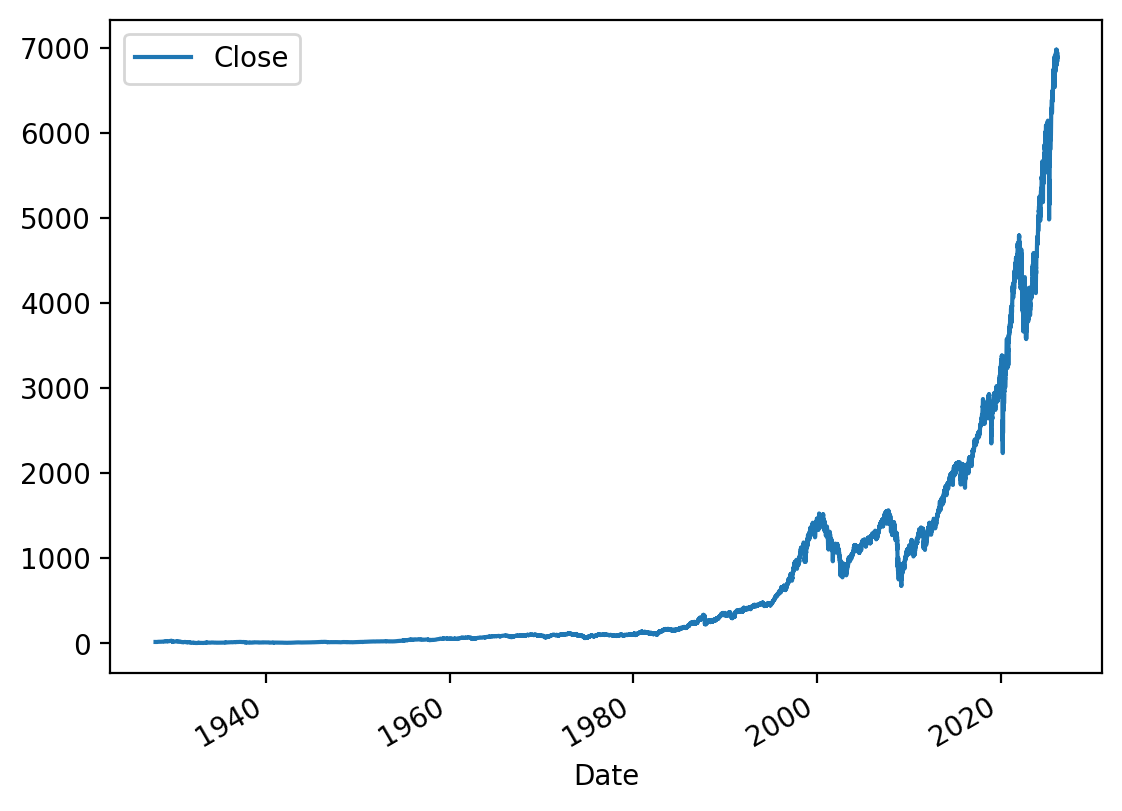

In [ ]:
sp500.plot.line(y="Close", use_index=True)

In [ ]:
# Data-Processing

In [ ]:
del sp500["Dividends"]
del sp500["Stock Splits"]

In [ ]:
sp500

,Open,High,Low,Close,Volume
Date,,,,,
1927-12-30 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0
1928-01-03 00:00:00-05:00,17.760000,17.760000,17.760000,17.760000,0
1928-01-04 00:00:00-05:00,17.719999,17.719999,17.719999,17.719999,0
1928-01-05 00:00:00-05:00,17.549999,17.549999,17.549999,17.549999,0
1928-01-06 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0
...,...,...,...,...,...
2026-02-24 00:00:00-05:00,6837.370117,6899.169922,6815.430176,6890.069824,5266090000
2026-02-25 00:00:00-05:00,6915.149902,6952.509766,6915.149902,6946.129883,5328060000
2026-02-26 00:00:00-05:00,6944.740234,6947.250000,6859.729980,6908.859863,5889550000


Setting up the Target

In [ ]:
sp500["Tomorrow"] = sp500["Close"].shift(-1)     # Show Tomorrow's Price

In [ ]:
sp500

,Open,High,Low,Close,Volume,Tomorrow
Date,,,,,,
1927-12-30 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,17.760000
1928-01-03 00:00:00-05:00,17.760000,17.760000,17.760000,17.760000,0,17.719999
1928-01-04 00:00:00-05:00,17.719999,17.719999,17.719999,17.719999,0,17.549999
1928-01-05 00:00:00-05:00,17.549999,17.549999,17.549999,17.549999,0,17.660000
1928-01-06 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,17.500000
...,...,...,...,...,...,...
2026-02-24 00:00:00-05:00,6837.370117,6899.169922,6815.430176,6890.069824,5266090000,6946.129883
2026-02-25 00:00:00-05:00,6915.149902,6952.509766,6915.149902,6946.129883,5328060000,6908.859863
2026-02-26 00:00:00-05:00,6944.740234,6947.250000,6859.729980,6908.859863,5889550000,6878.879883


In [ ]:
sp500["Target"] = (sp500["Tomorrow"]) > sp500["Close"].astype(int)

In [ ]:
sp500

,Open,High,Low,Close,Volume,Tomorrow,Target
Date,,,,,,,
1927-12-30 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,17.760000,True
1928-01-03 00:00:00-05:00,17.760000,17.760000,17.760000,17.760000,0,17.719999,True
1928-01-04 00:00:00-05:00,17.719999,17.719999,17.719999,17.719999,0,17.549999,True
1928-01-05 00:00:00-05:00,17.549999,17.549999,17.549999,17.549999,0,17.660000,True
1928-01-06 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,17.500000,True
...,...,...,...,...,...,...,...
2026-02-24 00:00:00-05:00,6837.370117,6899.169922,6815.430176,6890.069824,5266090000,6946.129883,True
2026-02-25 00:00:00-05:00,6915.149902,6952.509766,6915.149902,6946.129883,5328060000,6908.859863,False
2026-02-26 00:00:00-05:00,6944.740234,6947.250000,6859.729980,6908.859863,5889550000,6878.879883,False


In [ ]:
# The above output shows if the price goes up then it'll we true else false

In [ ]:
sp500 = sp500.loc["1990-01-01":].copy()
sp500

,Open,High,Low,Close,Volume,Tomorrow,Target
Date,,,,,,,
1990-01-02 00:00:00-05:00,353.399994,359.690002,351.980011,359.690002,162070000,358.760010,False
1990-01-03 00:00:00-05:00,359.690002,360.589996,357.890015,358.760010,192330000,355.670013,False
1990-01-04 00:00:00-05:00,358.760010,358.760010,352.890015,355.670013,177000000,352.200012,False
1990-01-05 00:00:00-05:00,355.670013,355.670013,351.350006,352.200012,158530000,353.790009,True
1990-01-08 00:00:00-05:00,352.200012,354.239990,350.540009,353.790009,140110000,349.619995,False
...,...,...,...,...,...,...,...
2026-02-24 00:00:00-05:00,6837.370117,6899.169922,6815.430176,6890.069824,5266090000,6946.129883,True
2026-02-25 00:00:00-05:00,6915.149902,6952.509766,6915.149902,6946.129883,5328060000,6908.859863,False
2026-02-26 00:00:00-05:00,6944.740234,6947.250000,6859.729980,6908.859863,5889550000,6878.879883,False


Training an Initial Machine Learning Model

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Random Forest Classifier work by training a bunch of individual decision trees with randomized parameter.
# Amd then averaging the results from those decision trees.
# Because of the process, It's resistant to overfit. Then can overfit but it's harder for them to overfit

# They run quite efficiently

# Thay can pick up non-linear tendencies in the data.

In the stock_price prediction, Most of the relationships are non-linear. If we can find linear relationship then we can make a lot of money

In [ ]:
model = RandomForestClassifier(n_estimators=1000, min_samples_split=100, random_state = 1)

# n_estimators = As large value, as better accuracy-result
# min_samples_split= Helps us to protect against overfitting
# Random_state = Means if we run the same model twice, the random no which will be generated will be in a predictable sequence each time. It helps while updating

In [ ]:
train = sp500.iloc[:-100]
test = sp500.iloc[-100:]

predictors = ["Close", "Volume", "Open", "High", "Low"]
model.fit(train[predictors], train["Target"])


RandomForestClassifier(min_samples_split=100, n_estimators=1000, random_state=1)

In [ ]:
from sklearn.metrics import precision_score
# what % of time market goes up when we say it to go up

preds = model.predict(test[predictors])
preds

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True, False,  True,  True, False,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True])

In [ ]:
preds = pd.Series(preds, index=test.index)

In [ ]:
precision_score(test["Target"], preds)

0.6020408163265306

Accuracy is not much great

In [ ]:
combined = pd.concat([test["Target"].astype(int), preds.astype(int)], axis=1)

<Axes: xlabel='Date'>

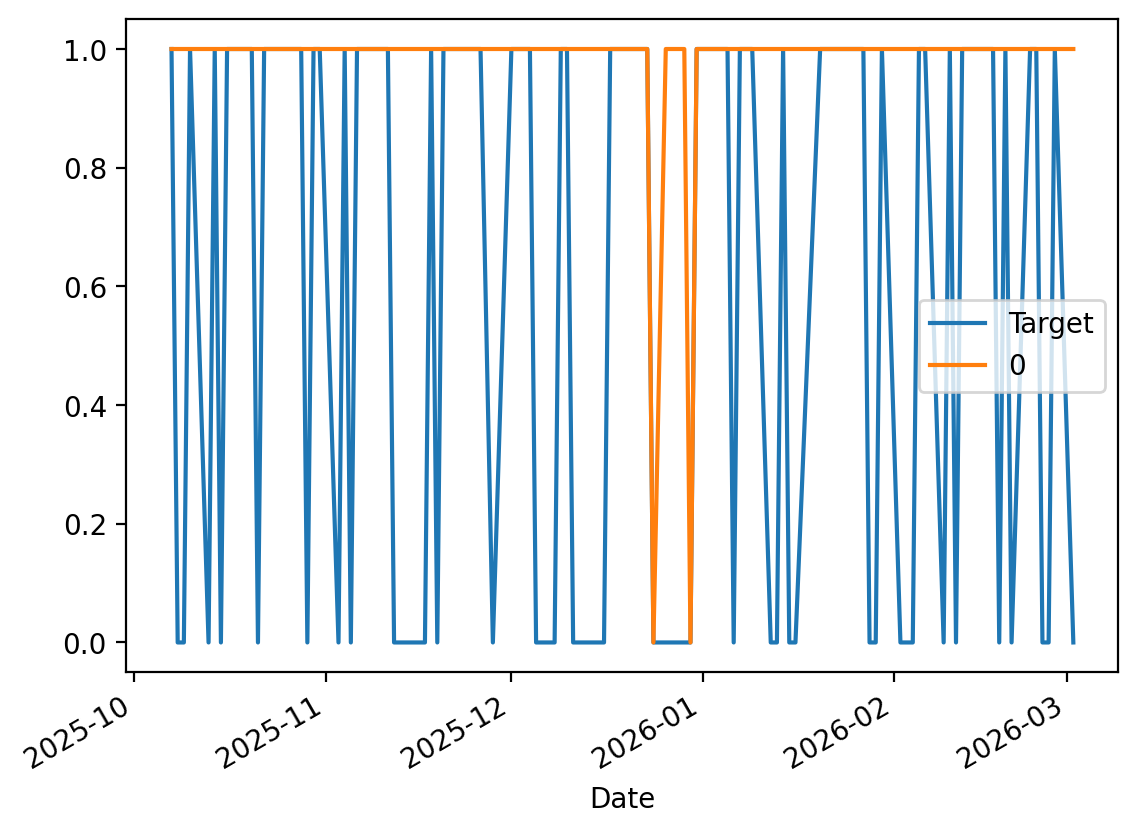

In [ ]:
combined.plot()

Building a BackTesting System

In [ ]:
def predict(train, test, predictors, model):
  model.fit(train[predictors], train["Target"])
  preds = model.predict(test[predictors])
  preds = pd.Series(preds, index=test.index, name="Predictions")
  combined = pd.concat([test["Target"], preds], axis=1)
  return combined

In [ ]:
def backtest(data, model, predictors, start=2500, step=250):

  # So, we are going to take 10 years of data and predict 11th year
  # Simillarly, again we'll take 11 yrs of data and predict 12th year
    # Again, we'll take 12 yrs of data and predict 13th year and so on.....

    all_predictions = []

    for i in range(start, data.shape[0], step):
      train = data.iloc[0:i].copy()
      test = data.iloc[i:(i+step)].copy()
      predictions = predict(train, test, predictors, model) # Corrected typo here
      all_predictions.append(predictions)
    return pd.concat(all_predictions)

In [ ]:
predictions = backtest(sp500, model, predictors)

In [ ]:
predictions["Predictions"].value_counts()

,count
Predictions,
False,3618
True,2989


In [ ]:
precision_score(predictions["Target"], predictions["Predictions"])

0.5520240883238541

In [ ]:
predictions["Target"].value_counts() / predictions.shape[0]

,count
Target,
True,0.553504
False,0.446496


Adding Additional Predictors to our Model

In [ ]:
horizons = [2,5,60,250,1000]
new_predictors = []

for horizon in horizons:
  rolling_averages = sp500.rolling(horizon).mean()

  ratio_column = f"Close_Ratio_{horizon}"
  sp500[ratio_column] = sp500["Close"] / rolling_averages["Close"]

  trend_column = f"Trend_{horizon}"
  sp500[trend_column] = sp500.shift(1).rolling(horizon).sum()["Target"]

  new_predictors += [ratio_column, trend_column]

In [ ]:
sp500

,Open,High,Low,Close,Volume,Tomorrow,Target,Close_Ratio_2,Trend_2,Close_Ratio_5,Trend_5,Close_Ratio_60,Trend_60,Close_Ratio_250,Trend_250,Close_Ratio_1000,Trend_1000
Date,,,,,,,,,,,,,,,,,
1990-01-02 00:00:00-05:00,353.399994,359.690002,351.980011,359.690002,162070000,358.760010,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1990-01-03 00:00:00-05:00,359.690002,360.589996,357.890015,358.760010,192330000,355.670013,False,0.998706,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1990-01-04 00:00:00-05:00,358.760010,358.760010,352.890015,355.670013,177000000,352.200012,False,0.995675,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1990-01-05 00:00:00-05:00,355.670013,355.670013,351.350006,352.200012,158530000,353.790009,True,0.995098,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1990-01-08 00:00:00-05:00,352.200012,354.239990,350.540009,353.790009,140110000,349.619995,False,1.002252,1.0,0.993731,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-02-24 00:00:00-05:00,6837.370117,6899.169922,6815.430176,6890.069824,5266090000,6946.129883,True,1.003811,1.0,1.002031,3.0,1.000351,35.0,1.085738,149.0,1.352356,547.0
2026-02-25 00:00:00-05:00,6915.149902,6952.509766,6915.149902,6946.129883,5328060000,6908.859863,False,1.004052,2.0,1.008283,3.0,1.008164,35.0,1.093890,149.0,1.362654,548.0
2026-02-26 00:00:00-05:00,6944.740234,6947.250000,6859.729980,6908.859863,5889550000,6878.879883,False,0.997310,1.0,1.001507,3.0,1.002610,34.0,1.087303,149.0,1.354672,547.0


In [ ]:
sp500 = sp500.dropna()

In [ ]:
sp500

,Open,High,Low,Close,Volume,Tomorrow,Target,Close_Ratio_2,Trend_2,Close_Ratio_5,Trend_5,Close_Ratio_60,Trend_60,Close_Ratio_250,Trend_250,Close_Ratio_1000,Trend_1000
Date,,,,,,,,,,,,,,,,,
1993-12-14 00:00:00-05:00,465.730011,466.119995,462.459991,463.059998,275050000,461.839996,False,0.997157,1.0,0.996617,2.0,1.000283,38.0,1.028047,152.0,1.176082,603.0
1993-12-15 00:00:00-05:00,463.059998,463.690002,461.839996,461.839996,331770000,463.339996,True,0.998681,0.0,0.995899,1.0,0.997329,38.0,1.025151,151.0,1.172676,603.0
1993-12-16 00:00:00-05:00,461.859985,463.980011,461.859985,463.339996,284620000,466.380005,True,1.001621,1.0,0.999495,2.0,1.000311,38.0,1.028274,152.0,1.176163,604.0
1993-12-17 00:00:00-05:00,463.339996,466.380005,463.339996,466.380005,363750000,465.850006,False,1.003270,2.0,1.004991,3.0,1.006561,38.0,1.034781,152.0,1.183537,605.0
1993-12-20 00:00:00-05:00,466.380005,466.899994,465.529999,465.850006,255900000,465.299988,True,0.999431,1.0,1.003784,2.0,1.005120,37.0,1.033359,152.0,1.181856,604.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-02-23 00:00:00-05:00,6901.250000,6916.959961,6819.819824,6837.750000,5638350000,6890.069824,True,0.994780,1.0,0.995779,3.0,0.993053,35.0,1.078129,148.0,1.342750,546.0
2026-02-24 00:00:00-05:00,6837.370117,6899.169922,6815.430176,6890.069824,5266090000,6946.129883,True,1.003811,1.0,1.002031,3.0,1.000351,35.0,1.085738,149.0,1.352356,547.0
2026-02-25 00:00:00-05:00,6915.149902,6952.509766,6915.149902,6946.129883,5328060000,6908.859863,False,1.004052,2.0,1.008283,3.0,1.008164,35.0,1.093890,149.0,1.362654,548.0


**Improving our Model**

In [ ]:
model = RandomForestClassifier(n_estimators=200, min_samples_split=50, random_state=1)

In [ ]:
def predict(train, test, predictors, model):
  model.fit(train[predictors], train["Target"])
  preds = model.predict_proba(test[predictors])[:,1]
  preds[preds >= 0.6] = 1
  preds[preds < 0.6] = 0
  preds = pd.Series(preds, index=test.index, name="Predictions")
  combined = pd.concat([test["Target"], preds], axis=1)
  return combined

In [ ]:
predictions = backtest(sp500, model, new_predictors)

In [ ]:
predictions["Predictions"].value_counts()

,count
Predictions,
0.0,4653
1.0,953


In [ ]:
precision_score(predictions["Target"], predictions["Predictions"])

0.5855194123819517